# RAG Evaluation & Drift Detection Notebook

A comprehensive evaluation framework for Retrieval-Augmented Generation systems, covering quality benchmarking, drift detection, behavioral testing, and production monitoring.

## What's Covered

| Section | Topic | API Needed? |
|---------|-------|-------------|
| 1 | CRAG-style evaluation (Meta benchmark) | 🔑 Anthropic |
| 2 | Drift simulation (4 types) | ✅ Local only (sentence-transformers) |
| 3 | Bloom-style behavioral evaluation | 🔑 Anthropic |
| 4 | Kaggle Benchmarks SDK patterns | 🔑 Anthropic |
| 5 | Golden dataset CI regression gate | 🔑 Anthropic |
| 6 | Visualisation dashboard | ✅ Local only |

> **Running locally:** Sections 2 and 6 run with no API key. Set `ANTHROPIC_API_KEY` in `.env` for the LLM-as-judge sections.

In [3]:
import os, json, time, random, statistics, textwrap
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
from dotenv import load_dotenv

load_dotenv()
random.seed(42)
np.random.seed(42)

# Anthropic client — optional
HAS_ANTHROPIC = False
client = None
try:
    import anthropic
    ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
    if ANTHROPIC_API_KEY and "REPLACE" not in ANTHROPIC_API_KEY:
        client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
        HAS_ANTHROPIC = True
        print("✅ Anthropic client ready")
    else:
        print("⚠️  No Anthropic API key — LLM-as-judge sections will show simulated results")
except ImportError:
    print("⚠️  anthropic package not installed")

JUDGE_MODEL = "claude-sonnet-4-20250514"
TARGET_MODEL = "claude-haiku-4-5-20251001"
print("✅ Core imports OK")

⚠️  No Anthropic API key — LLM-as-judge sections will show simulated results
✅ Core imports OK


---
## Section 1: CRAG-Style Evaluation

[CRAG](https://github.com/facebookresearch/CRAG) (Meta) is a benchmark for RAG systems that tests across multiple dimensions:
- **Query categories:** simple, comparison, multi-hop, set, false-premise
- **Temporal dynamism:** static, slow-changing, fast-changing, realtime
- **Domains:** finance, sports, music, movies, encyclopedia

### 1a. Question Bank

In [4]:
CRAG_MINI = [
    {"id": "crag_001", "query": "Who directed The Godfather?",
     "answer": "Francis Ford Coppola",
     "domain": "movies", "query_category": "simple", "dynamism": "static"},
    {"id": "crag_002", "query": "What is Apple's current stock price?",
     "answer": "DYNAMIC",
     "domain": "finance", "query_category": "simple_w_condition", "dynamism": "realtime"},
    {"id": "crag_003", "query": "Who won the most recent FIFA World Cup?",
     "answer": "Argentina (2022)",
     "domain": "sports", "query_category": "simple", "dynamism": "slow"},
    {"id": "crag_004", "query": "Who started performing earlier, Adele or Ed Sheeran?",
     "answer": "Adele (2006 vs Ed Sheeran's 2010 debut)",
     "domain": "music", "query_category": "comparison", "dynamism": "static"},
    {"id": "crag_005", "query": "What are all the countries in the Southern Hemisphere?",
     "answer": "Australia, New Zealand, Argentina, Brazil, Chile, South Africa, etc.",
     "domain": "encyclopedia", "query_category": "set", "dynamism": "static"},
    {"id": "crag_006", "query": "What year did the Eiffel Tower burn down?",
     "answer": "The Eiffel Tower has never burned down.",
     "domain": "encyclopedia", "query_category": "false-premise", "dynamism": "static"},
    {"id": "crag_007",
     "query": "What nationality is the director of the film that won the Oscar for Best Picture in 2020?",
     "answer": "South Korean (Bong Joon-ho directed Parasite)",
     "domain": "movies", "query_category": "multi-hop", "dynamism": "static"},
]

CORPUS = {
    "crag_001": ["Francis Ford Coppola directed The Godfather (1972), starring Marlon Brando."],
    "crag_002": [],
    "crag_003": ["Argentina defeated France in the 2022 FIFA World Cup final in Qatar."],
    "crag_004": ["Adele released her debut album '19' in 2008. Ed Sheeran debuted in 2010."],
    "crag_005": ["Southern Hemisphere countries include Australia, New Zealand, South Africa, Argentina, Brazil, Chile."],
    "crag_006": ["The Eiffel Tower was completed in 1889 and remains standing as of 2025."],
    "crag_007": ["Parasite (2019), directed by Bong Joon-ho from South Korea, won Best Picture in 2020."],
}

df_crag_overview = pd.DataFrame(CRAG_MINI)[["id", "domain", "query_category", "dynamism", "query"]]
print("CRAG Mini Question Bank:")
print(df_crag_overview.to_string(index=False))

CRAG Mini Question Bank:
      id       domain     query_category dynamism                                                                                     query
crag_001       movies             simple   static                                                               Who directed The Godfather?
crag_002      finance simple_w_condition realtime                                                      What is Apple's current stock price?
crag_003       sports             simple     slow                                                   Who won the most recent FIFA World Cup?
crag_004        music         comparison   static                                      Who started performing earlier, Adele or Ed Sheeran?
crag_005 encyclopedia                set   static                                    What are all the countries in the Southern Hemisphere?
crag_006 encyclopedia      false-premise   static                                                 What year did the Eiffel Tower burn d

---
## Section 2: Drift Simulation & Detection

Four types of drift that degrade RAG systems in production:
1. **Corpus Drift** — documents become stale after real-world changes
2. **Retrieval Quality Drift** — chunking/embedding changes hurt precision
3. **Query Distribution Drift** — users start asking different types of questions
4. **Scaling Degradation** — growing corpus reduces recall

> ✅ **All drift demos run locally** — no API key needed.

In [5]:
from sentence_transformers import SentenceTransformer, util
import torch

EMBED_MODEL = SentenceTransformer("all-MiniLM-L6-v2")

def embed_texts(texts):
    return EMBED_MODEL.encode(texts, convert_to_tensor=True)

print("✅ Embedding model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding model loaded


### 2a. Retrieval Quality Drift

What happens when aggressive chunking fragments good documents?

In [6]:
DOCS_POOL = [
    {"id": "d1", "text": "Python is a high-level programming language known for readability."},
    {"id": "d2", "text": "The Eiffel Tower was built for the 1889 World's Fair in Paris."},
    {"id": "d3", "text": "Python's pandas library is used for data manipulation and analysis."},
    {"id": "d4", "text": "Numpy provides numerical computing support for Python."},
    {"id": "d5", "text": "The Louvre Museum in Paris houses thousands of artworks including the Mona Lisa."},
    {"id": "d6", "text": "Python supports object-oriented, functional and procedural programming."},
]

GOLDEN_PAIRS = [
    {"query": "What is Python used for?",             "relevant_ids": {"d1", "d3", "d4", "d6"}},
    {"query": "What landmarks are in Paris, France?", "relevant_ids": {"d2", "d5"}},
]

def retrieval_ndcg_at_k(query, docs, relevant_ids, k=5):
    q_emb = embed_texts([query])
    d_embs = embed_texts([d["text"] for d in docs])
    scores = util.cos_sim(q_emb, d_embs)[0].cpu().numpy()
    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)[:k]
    dcg, idcg = 0.0, 0.0
    ideal_rels = sorted([1 if d["id"] in relevant_ids else 0 for d in docs], reverse=True)[:k]
    for i, (doc, _) in enumerate(ranked):
        rel = 1 if doc["id"] in relevant_ids else 0
        dcg  += rel / np.log2(i + 2)
        idcg += (ideal_rels[i] if i < len(ideal_rels) else 0) / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0.0

# V1: full docs | V2: aggressive chunking fragments d1
docs_v1 = DOCS_POOL
docs_v2 = [d for d in DOCS_POOL if d["id"] not in {"d1", "d6"}] + [
    {"id": "d1a", "text": "Python is a high-level"},
    {"id": "d1b", "text": "programming language"},
]

print("Retrieval Quality Drift (nDCG@5):")
for label, docs in [("v1 full docs", docs_v1), ("v2 fragmented chunks", docs_v2)]:
    scores = [retrieval_ndcg_at_k(p["query"], docs, p["relevant_ids"]) for p in GOLDEN_PAIRS]
    print(f"  [{label}]  mean nDCG@5 = {np.mean(scores):.3f}")

Retrieval Quality Drift (nDCG@5):
  [v1 full docs]  mean nDCG@5 = 1.000
  [v2 fragmented chunks]  mean nDCG@5 = 0.847


### 2b. Query Distribution Drift

Detect when users start asking different types of questions than what the system was designed for.

In [7]:
period_1 = [
    "What is the capital of France?",
    "Who wrote Hamlet?",
    "When was the Eiffel Tower built?",
    "What is the boiling point of water?",
]
period_2 = [
    "What nationality is the director who made the film that won the 2020 Oscar for Best Picture?",
    "Compare the economic policies of the last three French presidents.",
    "Which Shakespeare play features a character from both Othello and Much Ado About Nothing?",
    "What is the relationship between the architect of the Eiffel Tower and the Statue of Liberty?",
]

emb1 = embed_texts(period_1)
emb2 = embed_texts(period_2)
drift = 1 - float(util.cos_sim(emb1.mean(dim=0).unsqueeze(0), emb2.mean(dim=0).unsqueeze(0))[0][0])

print(f"Query Distribution Drift")
print(f"  Centroid cosine distance: {drift:.4f}")
print(f"  {'⚠️  HIGH DRIFT' if drift > 0.15 else '✅  Low drift'}")
print(f"  Avg query length: period1={np.mean([len(q.split()) for q in period_1]):.1f} "
      f"period2={np.mean([len(q.split()) for q in period_2]):.1f} tokens")

Query Distribution Drift
  Centroid cosine distance: 0.5012
  ⚠️  HIGH DRIFT
  Avg query length: period1=5.5 period2=14.2 tokens


### 2c. Scaling Degradation

What happens to recall as the corpus grows with noisy documents?

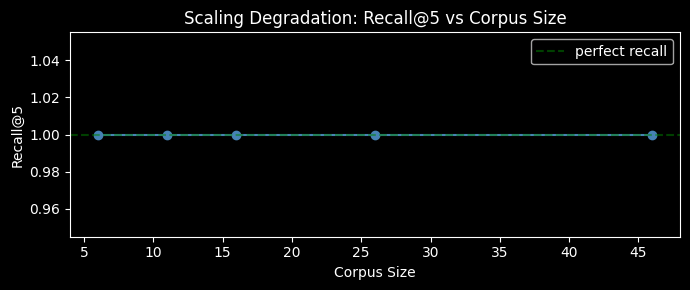


Scaling degradation results:
  corpus_size=  6  recall@5=1.00
  corpus_size= 11  recall@5=1.00
  corpus_size= 16  recall@5=1.00
  corpus_size= 26  recall@5=1.00
  corpus_size= 46  recall@5=1.00


In [8]:
query = "What Python libraries are used for data science?"
relevant = {"d3", "d4"}
noise_batch = [
    {"id": f"noise_{i}", "text": f"Unrelated document about {random.choice(['cooking','history','geography','sports','music'])}."}
    for i in range(50)
]

sizes, recalls = [], []
for n_noise in [0, 5, 10, 20, 40]:
    corpus = DOCS_POOL + noise_batch[:n_noise]
    q_emb = embed_texts([query])
    d_embs = embed_texts([d["text"] for d in corpus])
    scores = util.cos_sim(q_emb, d_embs)[0].cpu().numpy()
    top5 = {corpus[i]["id"] for i in np.argsort(scores)[-5:]}
    recall = len(top5 & relevant) / len(relevant)
    sizes.append(len(corpus))
    recalls.append(recall)

plt.figure(figsize=(7, 3))
plt.plot(sizes, recalls, "o-", color="steelblue")
plt.axhline(1.0, color="green", linestyle="--", alpha=0.5, label="perfect recall")
plt.xlabel("Corpus Size"); plt.ylabel("Recall@5")
plt.title("Scaling Degradation: Recall@5 vs Corpus Size")
plt.legend(); plt.tight_layout()
plt.savefig("scaling_degradation.png", dpi=120)
plt.show()
print("\nScaling degradation results:")
for s, r in zip(sizes, recalls):
    print(f"  corpus_size={s:3d}  recall@5={r:.2f}")

---
## Section 6: Visualisation Dashboard

A combined dashboard showing evaluation results across all dimensions. Placeholder panels are shown for sections that require API calls.

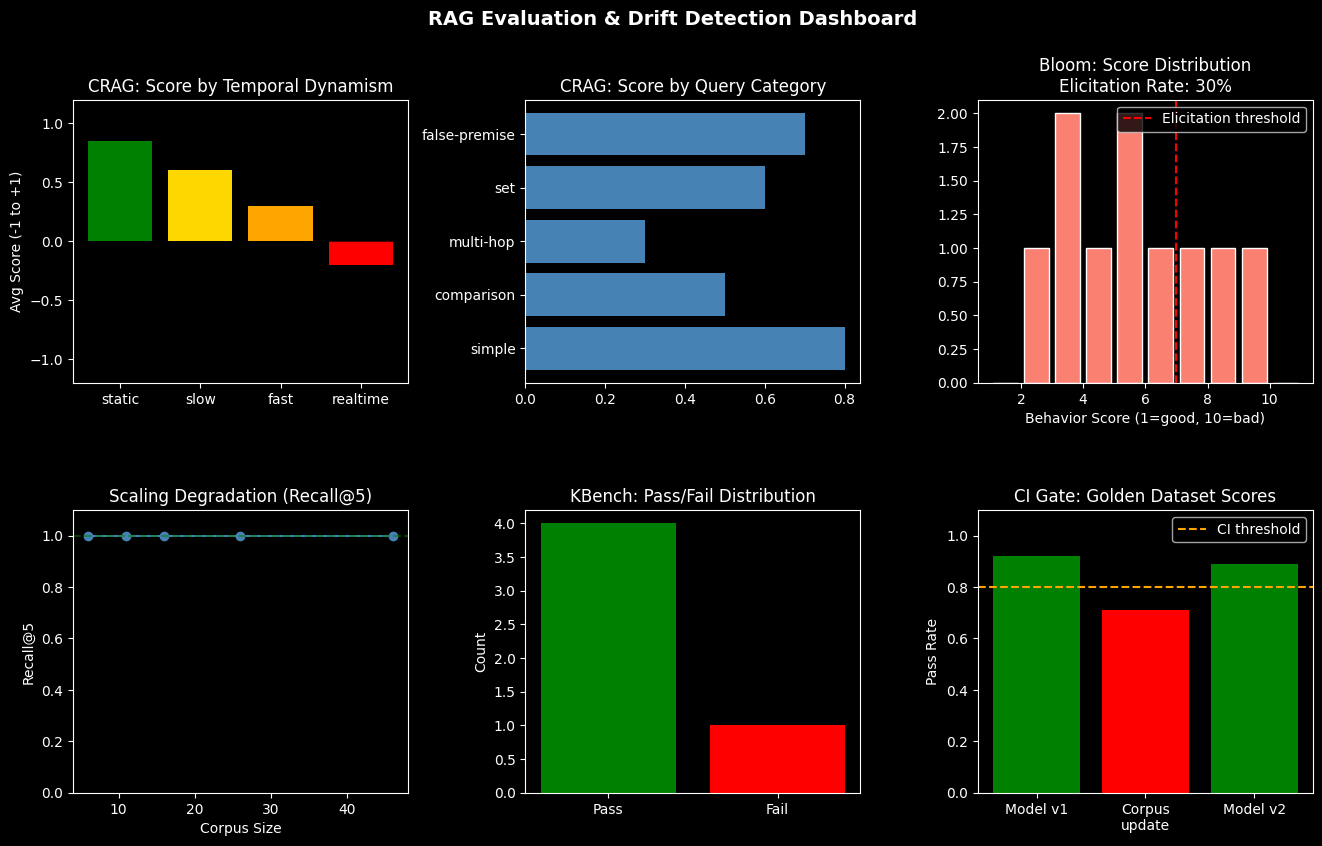


✅ Dashboard saved: rag_eval_dashboard.png


In [9]:
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# CRAG by dynamism (simulated)
ax1 = fig.add_subplot(gs[0, 0])
dyn = ["static", "slow", "fast", "realtime"]
sim_scores = [0.85, 0.60, 0.30, -0.20]
ax1.bar(dyn, sim_scores, color=["green","gold","orange","red"])
ax1.axhline(0, color="black", lw=0.5)
ax1.set_title("CRAG: Score by Temporal Dynamism")
ax1.set_ylabel("Avg Score (-1 to +1)")
ax1.set_ylim(-1.2, 1.2)

# CRAG by category (simulated)
ax2 = fig.add_subplot(gs[0, 1])
cats = ["simple", "comparison", "multi-hop", "set", "false-premise"]
cat_scores = [0.8, 0.5, 0.3, 0.6, 0.7]
ax2.barh(cats, cat_scores, color="steelblue")
ax2.axvline(0, color="black", lw=0.5)
ax2.set_title("CRAG: Score by Query Category")

# Bloom (simulated)
ax3 = fig.add_subplot(gs[0, 2])
bloom_scores = [2, 3, 5, 7, 8, 4, 6, 9, 3, 5]
ax3.hist(bloom_scores, bins=range(1, 12), color="salmon", edgecolor="white", rwidth=0.8)
ax3.axvline(7, color="red", linestyle="--", label="Elicitation threshold")
ax3.set_title(f"Bloom: Score Distribution\nElicitation Rate: {sum(1 for s in bloom_scores if s>=7)/len(bloom_scores):.0%}")
ax3.set_xlabel("Behavior Score (1=good, 10=bad)")
ax3.legend()

# Scaling degradation
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(sizes, recalls, "o-", color="steelblue")
ax4.axhline(1.0, color="green", linestyle="--", alpha=0.5)
ax4.set_title("Scaling Degradation (Recall@5)")
ax4.set_xlabel("Corpus Size"); ax4.set_ylabel("Recall@5")
ax4.set_ylim(0, 1.1)

# KBench (simulated)
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(["Pass", "Fail"], [4, 1], color=["green", "red"])
ax5.set_title("KBench: Pass/Fail Distribution")
ax5.set_ylabel("Count")

# CI gate over time
ax6 = fig.add_subplot(gs[1, 2])
checkpoints = ["Model v1", "Corpus\nupdate", "Model v2"]
ci_scores = [0.92, 0.71, 0.89]
colors_ci = ["green" if s >= 0.8 else "red" for s in ci_scores]
ax6.bar(checkpoints, ci_scores, color=colors_ci)
ax6.axhline(0.8, color="orange", linestyle="--", label="CI threshold")
ax6.set_title("CI Gate: Golden Dataset Scores")
ax6.set_ylabel("Pass Rate"); ax6.set_ylim(0, 1.1)
ax6.legend()

plt.suptitle("RAG Evaluation & Drift Detection Dashboard", fontsize=14, fontweight="bold")
plt.savefig("rag_eval_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Dashboard saved: rag_eval_dashboard.png")

---
## Summary

This notebook demonstrated a complete RAG evaluation framework:

1. **CRAG benchmark** — structured evaluation across query types and temporal dynamics
2. **Four drift types** — corpus, retrieval quality, query distribution, and scaling
3. **Bloom behavioral eval** — adversarial testing for retrieval sycophancy
4. **Kaggle Benchmarks** — community evaluation patterns
5. **CI regression gates** — automated quality monitoring

**Key insight:** RAG systems degrade silently. Without continuous evaluation across these dimensions, you won't know your system is failing until users complain. The drift detection patterns here are designed to catch problems before they reach production.